# Proyek Analisis Data: [Bike-sharing-dataset.zip]
- **Nama:** [Meyrica Dianiken Cintami]
- **Email:** [meyricadianikencintami8@gmail.com]
- **ID Dicoding:** [CDCC115D6X1800]

## Menentukan Pertanyaan Bisnis

1.   Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda selama tahun 2011–2012?
2.   Pada jam berapa terjadi puncak penyewaan sepeda, dan bagaimana perbedaan pola jam sibuk antara hari kerja dan hari libur selama tahun 2011–2012?
3.   Bagaimana tren jumlah penyewaan sepeda dari waktu ke waktu, dan apakah terdapat perbedaan antara pengguna kasual dan pengguna terdaftar selama tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from google.colab import files

**Penjelasan Singkat :**
* Pandas ini digunakan untuk membaca tabel, mengolah tabel, dan memanipulasi kolom dengan mudah.
* numpy in digunakan untuk perhitungan numerik dan operasi matematika.
* matplotlib.pyplot ini digunakan untuk membuat grafik dasar.
* seaborn ini digunakan untuk membuat visualisasi data yang lebih menarik.
* sns.set(style='whitegrid') ini untuk mengatur tampilan grafik agar lebih rapih dengan grid.
* download file yang sudah di olah

## Data Wrangling

### Gathering Data

In [37]:
hour_df = pd.read_csv('hour.csv') #membaca data

#menampilkan 5 data teratas
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [38]:
day_df = pd.read_csv('day.csv') #membaca data
day_df.head() #menampilkan 5 data teratas

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
* Dengan fungsi (pd.read.df) data berhasil dibaca dengan baik dan siap digunakan untuk analisis.
* Dari 5 data awal, kita bisa melihat gambaran isi tiap variabel. Misalnya, kolom holiday berisi nilai 1 (iya) dan 0 (tidak), serta kolom dteday memiliki format tanggal (tahun-bulan-hari) yang memudahkan proses pembersihan data.


### Assessing Data

In [39]:
print("1. Informasi Struktur dan Tipe Data:") # Baca informasi dan tipe data
print('informasi data harian')
day_df.info()
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n2. Pengecekan Data Missing Value:") # Cek adanya Missing Value
print("\nMissing Values Dataset Harian:")
print(day_df.isnull().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n3. Pengecekan Duplikasi Data:") # Cek duplikasi
print("\nJumlah Duplikasi Dataset Harian:")
print(day_df.duplicated().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n4. Ringkasan Statistik Data Numerik:") # Statistik deskriptif
print("\nStatistik Dataset Harian:")
display(day_df.describe())

1. Informasi Struktur dan Tipe Data:
informasi data harian
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
----------------------------------

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [40]:
print("1. Informasi Struktur dan Tipe Data:") # Baca informasi dan tipe data
print('informasi data per-jam')
hour_df.info()
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n2. Pengecekan Data Missing Value:") # Cek adanya Missing Value
print("\nMissing Values Dataset Per-Jam:")
print(hour_df.isnull().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n3. Pengecekan Duplikasi Data:") # Cek duplikasi
print("\nJumlah Duplikasi Dataset Per-Jam:")
print(hour_df.duplicated().sum())
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("\n4. Ringkasan Statistik Data Numerik:") # Statistik deskriptif
print("\nStatistik Dataset Per-Jam:")
display(hour_df.describe())

1. Informasi Struktur dan Tipe Data:
informasi data per-jam
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usag

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing value, jadi datanya sudah lengkap dan bisa langsung dipakai untuk analisis.
- Tidak ada data duplikat di kedua dataset, jadi datanya cukup bersih dan tidak ada pengulangan yang bisa bikin hasil jadi bias.
- kolom *dteday* masih berupa object, jadi perlu diubah ke datetime supaya lebih gampang dipakai untuk analisis waktu.
- Terlihat kalau beberapa variabel seperti suhu, kelembapan, dan kecepatan angin sudah dalam bentuk normalisasi (0–1), jadi perlu diperhatikan saat membaca nilainya.
- Nilai pada kolom cnt cukup bervariasi, yang berarti jumlah penyewaan sepeda bisa berubah-ubah tergantung kondisi tertentu.

### Cleaning Data

In [41]:
print("1. Mengubah tipe data kolom tanggal") # Mengubah tipe data kolom tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
print("Tipe data dteday (Day):", day_df['dteday'].dtype)
print("Tipe data dteday (Hour):", hour_df['dteday'].dtype)
print("-" * 60) # Garis pemisah biar output terlihat lebih rapih

print("2. Drop kolom yang nggak kepakai") # Drop kolom yang nggak kepakai
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)
print("Columns Day:", day_df.columns)
print("Columns Hour:", hour_df.columns)

1. Mengubah tipe data kolom tanggal
Tipe data dteday (Day): datetime64[ns]
Tipe data dteday (Hour): datetime64[ns]
------------------------------------------------------------
2. Drop kolom yang nggak kepakai
Columns Day: Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')
Columns Hour: Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


**Insight:**
- Kolom dteday sudah diubah ke format datetime, jadi lebih gampang dipakai untuk analisis yang berkaitan dengan waktu.
- Kolom instant dihapus karena tidak terlalu berpengaruh dalam analisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [42]:
# Menampilkan 5 baris pertama dari DataFrame yang sudah dibersihkan
print("Data Setelah Cleaning Day:")
display(day_df.head())
print("\nData Setelah Cleaning Hour:")
display(hour_df.head())
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 1. Memeriksa kembali struktur data dan tipe data
print("\n---1. Informasi Struktur dan Tipe Data ---")
print("\n--- Informasi Struktur dan Tipe Data Day ---")
day_df.info()
print("\n--- Informasi Struktur dan Tipe Data Hour ---")
hour_df.info()
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 2. Cuaca terhadap Jumlah Penyewaan
print("\n---2. Korelasi antara cuaca dan jumlah penyewaan: ---")
print(day_df[['temp','hum','windspeed','cnt']].corr())
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

# 3. Jam Paling Ramai
print("\n---3. Rata-rata penyewaan sepeda per jam: ---")
avg_hour = hour_df.groupby('hr')['cnt'].mean()
print(avg_hour)
print("-" * 100) # Garis pemisah biar output terlihat lebih rapih

#4. Hari Paling Ramai
print("\n---4. Rata-rata penyewaan sepeda per hari :---")
avg_day = hour_df.groupby('weekday')['cnt'].mean()
print(avg_day)
print("-" * 100)

# 5. Petbandingan hari kerja dan hari libur
print("\n---5. Perbandingan total rental penyewaan hari kerja dan hari libur :---")
avg_workingday = day_df.groupby('workingday')['cnt'].mean()
display(avg_workingday)
print("-" * 100)

# 6. Rata-rata penyewaan berdasarkan cuaca
print("\n---6. Rata-rata penyewaan berdasarkan cuaca:---")
avg_weather = day_df.groupby('weathersit')['cnt'].mean()
display(avg_weather)
print("-" * 100)

#7. Perbandingan pengunjung
print("\n---7. Perbandingan pengunjung:---")
trend_df = day_df[['dteday', 'casual', 'registered', 'cnt']]
display(trend_df.head())

Data Setelah Cleaning Day:


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Setelah Cleaning Hour:


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


----------------------------------------------------------------------------------------------------

---1. Informasi Struktur dan Tipe Data ---

--- Informasi Struktur dan Tipe Data Day ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   season      731 non-null    int64         
 2   yr          731 non-null    int64         
 3   mnth        731 non-null    int64         
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    int64         
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    int64         
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null   

,cnt
workingday,
0,4330.168831
1,4584.820000


----------------------------------------------------------------------------------------------------

---6. Rata-rata penyewaan berdasarkan cuaca:---


,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


----------------------------------------------------------------------------------------------------

---7. Perbandingan pengunjung:---


,dteday,casual,registered,cnt
0,2011-01-01,331,654,985
1,2011-01-02,131,670,801
2,2011-01-03,120,1229,1349
3,2011-01-04,108,1454,1562
4,2011-01-05,82,1518,1600


**Insight:**
- Suhu memiliki hubungan positif dengan jumlah penyewaan sepeda, di mana semakin tinggi suhu, jumlah penyewaan cenderung meningkat, meskipun masih dipengaruhi faktor lain.
- Kondisi cuaca juga berpengaruh, di mana cuaca cerah memiliki jumlah penyewaan tertinggi, sedangkan saat cuaca memburuk, jumlah penyewaan menurun.
- Penyewaan sepeda paling rendah terjadi pada dini hari, lalu meningkat pada pagi hari dan mencapai puncak, serta kembali meningkat pada sore hari sebelum menurun di malam hari.
- Jumlah penyewaan sepeda relatif stabil di setiap hari, dengan sedikit peningkatan pada pertengahan hingga akhir minggu.
- dilihat dari perbandingan pengunjung yg terdaftar(registed) atau yang sering kembali mengunjungi otlet lebih banyak daripada yang casual.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
1.   Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda selama tahun 2011–2012?


--- Korelasi antara cuaca dan jumlah penyewaan: ---
               temp       hum  windspeed       cnt
temp       1.000000  0.126963  -0.157944  0.627494
hum        0.126963  1.000000  -0.248489 -0.100659
windspeed -0.157944 -0.248489   1.000000 -0.234545
cnt        0.627494 -0.100659  -0.234545  1.000000


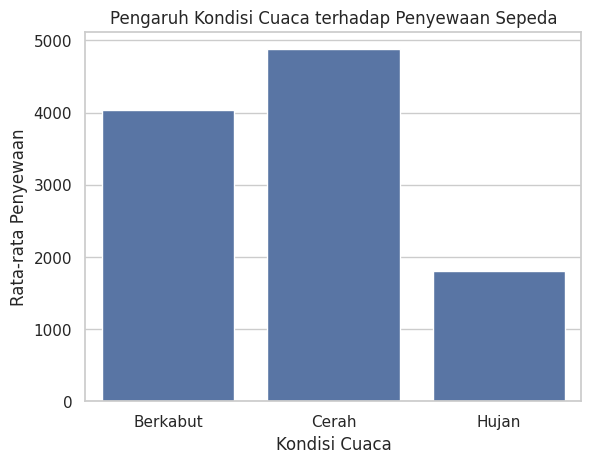

In [33]:
print("\n--- Korelasi antara cuaca dan jumlah penyewaan: ---") # Kondisi cuaca terhadap jumlah penyewaan
print(day_df[['temp','hum','windspeed','cnt']].corr())

# Label cuaca
weather_labels = {
    1: "Cerah",
    2: "Berkabut",
    3: "Hujan",
}

day_df['weather_label'] = day_df['weathersit'].map(weather_labels)
avg_weather = day_df.groupby('weather_label')['cnt'].mean().reset_index()

# Plot
plt.figure()
sns.barplot(x='weather_label', y='cnt', data=avg_weather)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda')
plt.show()

* temp → cnt = 0.627 =  Suhu memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan -> Makin cerah cuaca makin banyak orang nyewa sepeda.
* hum → cnt = -0.10 = Kelembapan memiliki hubungan negatif yang sangat lemah terhadap penyewaan -> Berkabut = pengaruhnya tidak terlalu signifikan.
* windspeed → cnt = -0.23 = Kecepatan angin memiliki hubungan negatif terhadap penyewaan -> Hujan = jumlah penyewaan cenderung menurun.
* dilihat hasil visualisasi weathersit = (cuaca cerah) = paling tinggi, dibandingkan saat berkabut dan hujan

### Pertanyaan 2:
2.   Pada jam berapa terjadi puncak penyewaan sepeda, dan bagaimana perbedaan pola jam sibuk antara hari kerja dan hari libur selama tahun 2011–2012?


---. Rata-rata penyewaan sepeda per-Jam (hari kerta VS hari libur): ---


day_type,Hari Kerja,Hari Libur
hr,,
0,36.786290,90.800000
1,16.552632,69.508696
2,8.683778,53.171053
3,4.942553,25.775330
4,5.429787,8.264317
5,24.913131,8.689189
6,102.500000,18.742358
7,290.612903,43.406926
8,477.006048,105.653680


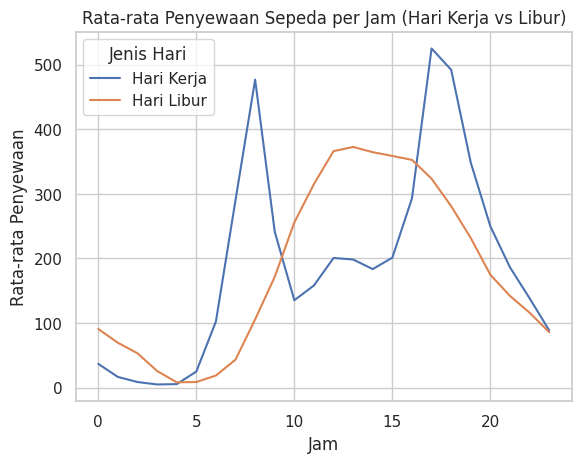

In [34]:
print("\n---. Rata-rata penyewaan sepeda per-Jam (hari kerta VS hari libur): ---") # Menghitung rata-rata penyewaan sepeda per-jam (hari kerja VS libur)
hour_df['day_type'] = hour_df['workingday'].map({
    0: 'Hari Libur',
    1: 'Hari Kerja'
})

# Hitung rata-rata
avg_hour = hour_df.groupby(['hr', 'day_type'])['cnt'].mean().reset_index()
avg_hour_table = avg_hour.pivot(index='hr', columns='day_type', values='cnt')
display(avg_hour_table)

plt.figure()
sns.lineplot(data=avg_hour, x='hr', y='cnt', hue='day_type')
plt.title('Rata-rata Penyewaan Sepeda per Jam (Hari Kerja vs Libur)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend(title='Jenis Hari')
plt.show()

* Jumlah penyewaan sepeda paling tinggi terjadi pada pagi hari sekitar pukul 07.00–08.00 dan mencapai puncak tertinggi pada sore hari sekitar pukul 17.00–18.00.
*  pengunjung di hari kerja cenderung lebih tinggi di bandingkan hari libur.


---. Rata-rata penyewaan sepeda per hari: ---
  weekday_label         cnt
0        Minggu  177.468825
1         Senin  183.744655
2        Selasa  191.238891
3          Rabu  191.130505
4         Kamis  196.436665
5         Jumat  196.135907
6         Sabtu  190.209793


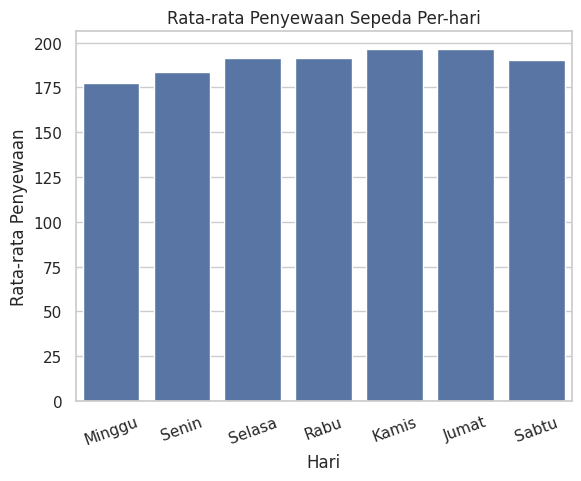

In [43]:
print("\n---. Rata-rata penyewaan sepeda per hari: ---") # Menghitung rata-rata penyewaan sepeda per hari
day_labels = {
    0: 'Minggu',
    1: 'Senin',
    2: 'Selasa',
    3: 'Rabu',
    4: 'Kamis',
    5: 'Jumat',
    6: 'Sabtu'
}

hour_df['weekday_label'] = hour_df['weekday'].map(day_labels)

avg_day = hour_df.groupby('weekday_label')['cnt'].mean().reindex(day_labels.values()).reset_index()
print(avg_day)
plt.figure()
sns.barplot(x='weekday_label', y='cnt', data=avg_day)
plt.title('Rata-rata Penyewaan Sepeda Per-hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=20)
plt.show()

* Penyewaan sepeda relatif stabil tiap hari, tapi mulai meningkat di hari Jumat dan Sabtu, jumlah penyewaan di dua hari ini justru lebih tinggi dibanding hari Minggu.

###Pertanyaan 3:

3. Bagaimana tren jumlah penyewaan sepeda dari waktu ke waktu, dan apakah terdapat perbedaan antara pengguna kasual dan pengguna terdaftar selama tahun 2011–2012?


---. Perbandingan Rata-rata Pengguna: ---


,Jenis Pengguna,Rata-rata Penyewaan
0,casual,848.176471
1,registered,3656.172367


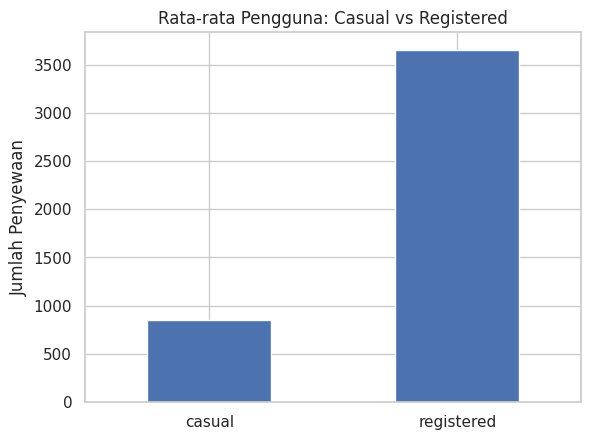

In [44]:
print("\n---. Perbandingan Rata-rata Pengguna: ---") # Menghitung rata-rata pengguna Casual VS registered
# Hitung rata-rata
avg_users = day_df[['casual','registered']].mean()
avg_users_df = avg_users.reset_index()
avg_users_df.columns = ['Jenis Pengguna', 'Rata-rata Penyewaan']

display(avg_users_df)
avg_users.plot(kind='bar')
plt.title('Rata-rata Pengguna: Casual vs Registered')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(rotation=0)
plt.show()

- Rata-rata pengunjung registered/terdaftar (sering kembali ke otlet) = 3656.172367
 lebih tinggi dari pada casual = 848.176471.


---. Rata-rata penyewaan per-tahun: ---


,year,cnt
0,2011,1243103
1,2012,2049576


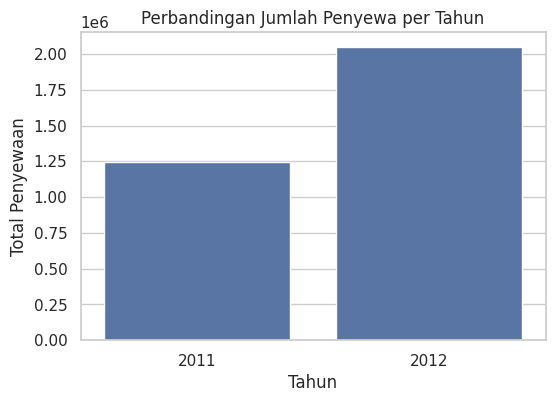


---. Rata-rata penyewaan per-bulan: ---


,month_name,cnt
0,Jan,2176.338710
1,Feb,2655.298246
2,Mar,3692.258065
3,Apr,4484.900000
4,Mei,5349.774194
5,Jun,5772.366667
6,Jul,5563.677419
7,Agu,5664.419355
8,Sep,5766.516667
9,Okt,5199.225806


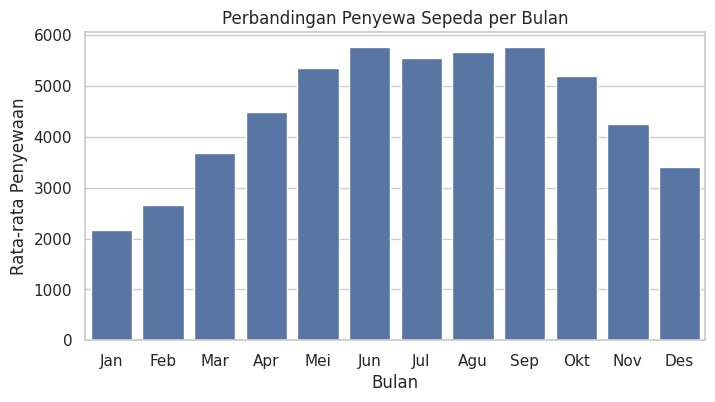

In [45]:
print("\n---. Rata-rata penyewaan per-tahun: ---") # Menghitung rata-rata penyewaan sepeda per yahun
# Label tahun
day_df['year'] = day_df['yr'].map({
    0: '2011',
    1: '2012'
})

# Total penyewaan per tahun
yearly_total = day_df.groupby('year')['cnt'].sum().reset_index()
display(yearly_total)

plt.figure(figsize=(6,4))
sns.barplot(data=yearly_total, x='year', y='cnt')
plt.title('Perbandingan Jumlah Penyewa per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Total Penyewaan')
plt.show()

print("\n---. Rata-rata penyewaan per-bulan: ---") # Menghitung rata-rata penyewaan sepeda per bulan
# Label bulan
month_labels = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'Mei', 6: 'Jun', 7: 'Jul', 8: 'Agu',
    9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

day_df['month_name'] = day_df['mnth'].map(month_labels)
monthly_avg = day_df.groupby('month_name')['cnt'].mean().reindex(month_labels.values()).reset_index()
display(monthly_avg)

plt.figure(figsize=(8,4))
sns.barplot(data=monthly_avg, x='month_name', y='cnt')
plt.title('Perbandingan Penyewa Sepeda per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=0)
plt.show()


--- Rata-rata kondisi cuaca setiap bulan: ---


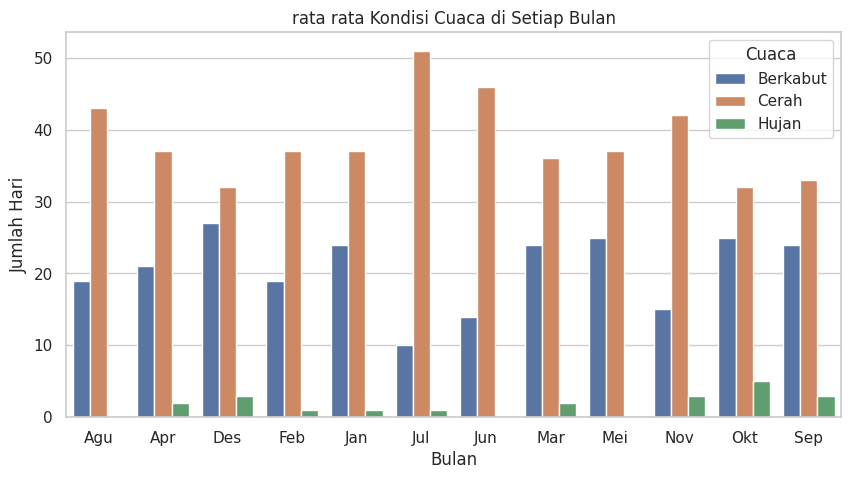

In [46]:
print("\n--- Rata-rata kondisi cuaca setiap bulan: ---") # Menghitung rata-rata kondisi cuaca setiao bulan
# Label bulan
month_labels = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'Mei', 6: 'Jun', 7: 'Jul', 8: 'Agu',
    9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}
day_df['month_name'] = day_df['mnth'].map(month_labels)

# label cuaca
weather_labels = {
    1: "Cerah",
    2: "Berkabut",
    3: "Hujan",
}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)

# jumlah kemunculan
weather_month = day_df.groupby(['month_name', 'weather_label']).size().reset_index(name='jumlah')

plt.figure(figsize=(10,5))
sns.barplot(data=weather_month, x='month_name', y='jumlah', hue='weather_label')
plt.title('rata rata Kondisi Cuaca di Setiap Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Hari')
plt.xticks(rotation=0)
plt.legend(title='Cuaca')
plt.show()

- pengunjung di tahun 2012 lebih tinggi dari 2011
- Penyewaan sepeda meningkat dari awal tahun dan mencapai puncak di pertengahan tahun (Jun–Sep), lalu menurun kembali di akhir tahun.
- Cuaca cerah mendominasi sepanjang tahun, terutama di pertengahan tahun, sementara hujan meningkat di akhir tahun.

## Analisis Lanjutan (Opsional)

### Conclusion:

1. Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda selama tahun 2011–2012?
    - Rata-rata jumlah penyewaan sepeda cenderung lebih tinggi saat kondisi cuaca cerah dibandingkan saat berkabut ataupun hujan. Ini menunjukkan bahwa cuaca memiliki pengaruh terhadap minat pengguna dalam menyewa sepeda.
2. Pada jam berapa terjadi puncak penyewaan sepeda, dan bagaimana perbedaan pola jam sibuk antara hari kerja dan hari libur selama tahun 2011–2012?
    - Naiknya penyewaan sepeda terjadi pada pagi hari sekitar pukul 07.00–08.00 dan mencapai titik tertinggi pada sore hari sekitar pukul 17.00–18.00. Pola ini =  dipengaruhi oleh aktivitas harian pengunjung (berangkat dan pulang kerja) dan kecenderungan menghindari cuaca panas di siang hari. Dan jumlah penyewaan pada hari kerja cenderung lebih tinggi dibandingkan hari libur.
3. Bagaimana tren jumlah penyewaan sepeda dari waktu ke waktu, dan apakah terdapat perbedaan antara pengguna kasual dan pengguna terdaftar selama tahun 2011–2012?
    - Jumlah penyewaan sepeda menunjukkan tren meningkat dari tahun 2011 ke 2012. Pengguna terdaftar (registered) memiliki jumlah yang lebih tinggi dibandingkan pengguna kasual (casual) = bahwa sebagian besar pengguna itu pelanggan yang menggunakan layanan secara rutin. Selain itu, penyewaan sepeda meningkat dari awal tahun, mencapai pada pertengahan tahun (Juni–September), dan menurun kembali di akhir tahun, yang dipengaruhi oleh perubahan kondisi cuaca musiman.

### Recommendation:


1. Pengaruh kondisi cuaca terhadap penyewaan sepeda
    - Menambah jumlah sepeda dan kesiapan operasional pada hari dengan cuaca cerah.
    - Berikan promo atau diskon pada saat cuaca kurang baik untuk menjaga jumlah penyewaan.
    - Sediakan informasi cuaca atau rekomendasi waktu terbaik untuk menyewa.
2. Pola jam sibuk penyewaan sepeda
    - Menambah ketersediaan sepeda pada jam sibuk untuk menghindari kekurangan unit.
    - Lakukan maintenance di luar jam sibuk agar tidak mengganggu operasional.
    - Penyesuaian tarif atau paket atau member langganan untuk pengguna rutin.
3. Tren penyewaan dan jenis pengguna
    - Fokus mempertahankan pengguna terdaftar dengan program paket atau member langganan.
    - Meningkatkan promosi untuk menarik pengguna kasual agar menjadi pengguna tetap.

In [47]:
# Menggabungkan data berdasarkan tanggal
all_data = pd.merge(hour_df, day_df, on='dteday', how='inner')

# Simpan ke file CSV
all_data.to_csv('all_data.csv', index=False)
print("File all_data.csv berhasil dibuat")
files.download('all_data.csv')

File all_data.csv berhasil dibuat


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>